In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.metrics import log_loss
from sklearn.metrics import accuracy_score

# 1 Gradient Boosting for regression

1. Generate and plot these data like shown in Figure 1.

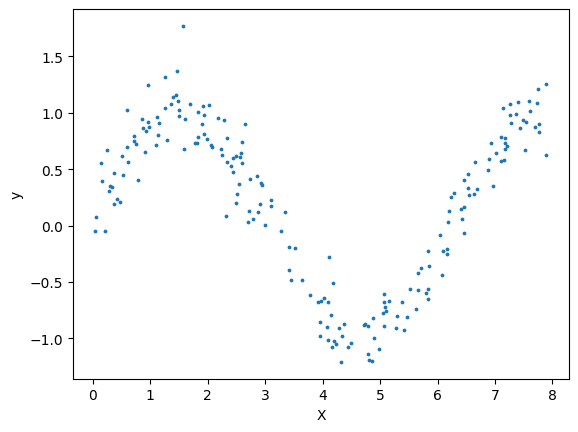

In [2]:
np.random.seed(42)

n = 200
X = np.random.uniform(0, 8, n)
u = np.random.normal(0, 0.2, n)
y = np.sin(X) + u

order = np.argsort(X)
X_sorted = X[order]
y_sorted = y[order]

# Plot
plt.figure()
plt.scatter(X_sorted, y_sorted, s=3)
plt.xlabel("X")
plt.ylabel("y")
plt.show()

2. You will now define a Python class MSDGradientBoostingRegressor that implements the Gradient Boosting method for regression. Use the following template and fill in the missing parts :

In [3]:
class MSDGradientBoostingRegressor:
    def __init__(self, max_depth=3, n_iterations=100, learning_rate=0.1):
        self.max_depth = max_depth
        self.n_iterations = n_iterations
        self.learning_rate = learning_rate

    def _loss(self, y, y_pred):
        return 0.5 * np.mean((y - y_pred) ** 2)

    def _negative_gradient(self, y, y_pred):
        return y - y_pred

    def fit(self, X, y):
        # init. the first weak model using a dummy regressor
        self.init_ = DummyRegressor(strategy="mean")
        self.init_.fit(X, y)

        y_pred = self.init_.predict(X)

        # store the weak models and their corresponding alphas
        self.estimators_ = []
        self.alphas_ = []

        # fit the weak models
        for i in range(self.n_iterations):
            # residuals
            residuals = self._negative_gradient(y, y_pred)

            # Fit tree
            tree = DecisionTreeRegressor(max_depth=self.max_depth)
            tree.fit(X, residuals)

            # preds
            h = tree.predict(X)

            # alpha
            alpha = np.dot(residuals, h) / np.dot(h, h)

            y_pred += self.learning_rate * alpha * h

            # Save model
            self.estimators_.append(tree)
            self.alphas_.append(alpha)

        return self

    def predict(self, X):
        y_pred = self.init_.predict(X)

        for alpha, tree in zip(self.alphas_, self.estimators_):
            y_pred += self.learning_rate * alpha * tree.predict(X)

        return y_pred

3. Plot the predictions of your Gradient Boosting model on the synthetic dataset.


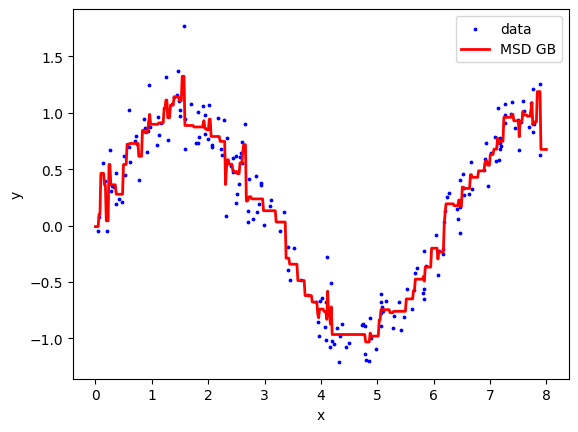

In [4]:
X = X.reshape(-1, 1)

# Train
model = MSDGradientBoostingRegressor(
    max_depth=3,
    n_iterations=100,
    learning_rate=0.1
)
model.fit(X, y)

#  test
X_test = np.linspace(0, 8, 500).reshape(-1, 1)
y_pred = model.predict(X_test)

# Plot
plt.figure()
plt.scatter(X, y, label="data", s=3, color="blue")
plt.plot(X_test, y_pred, label="MSD GB", linewidth=2, color="red")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

4. Modify your implementation to be able to plot the evolution of the loss function with respect to the number of iterations

In [5]:
class MSDGradientBoostingRegressor:
    def __init__(self, max_depth=3, n_iterations=100, learning_rate=0.1):
        self.max_depth = max_depth
        self.n_iterations = n_iterations
        self.learning_rate = learning_rate

    def _loss(self, y, y_pred):
        return 0.5 * np.mean((y - y_pred) ** 2)

    def _negative_gradient(self, y, y_pred):
        return y - y_pred

    def fit(self, X, y):
        # init. the first weak model using a dummy regressor
        self.init_ = DummyRegressor(strategy="mean")
        self.init_.fit(X, y)
        y_pred = self.init_.predict(X)

        # store the weak models and their corresponding alphas
        self.estimators_ = []
        self.alphas_ = []
        self.losses_ = []

        # Initial loss
        self.losses_.append(self._loss(y, y_pred))

        # fit the weak models
        for i in range(self.n_iterations):
            residuals = self._negative_gradient(y, y_pred)

            tree = DecisionTreeRegressor(max_depth=self.max_depth)
            tree.fit(X, residuals)

            h = tree.predict(X)

            alpha = np.dot(residuals, h) / np.dot(h, h)

            y_pred += self.learning_rate * alpha * h

            self.estimators_.append(tree)
            self.alphas_.append(alpha)

            # Store loss
            self.losses_.append(self._loss(y, y_pred))

        return self

    def predict(self, X):
        y_pred = self.init_.predict(X)

        for alpha, tree in zip(self.alphas_, self.estimators_):
            y_pred += self.learning_rate * alpha * tree.predict(X)

        return y_pred

In [6]:
# X = X.reshape(-1, 1)

# Train
model = MSDGradientBoostingRegressor(
    max_depth=3,
    n_iterations=100,
    learning_rate=0.1
)
model.fit(X, y)

X_test = np.linspace(0, 8, 500).reshape(-1, 1)
y_pred = model.predict(X_test)


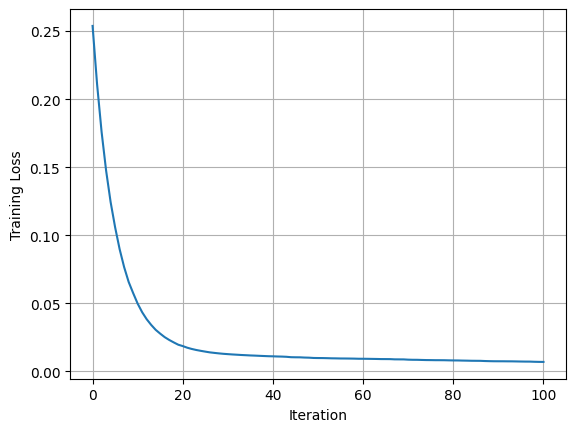

In [7]:
plt.figure()
plt.plot(model.losses_)
plt.xlabel("Iteration")
plt.ylabel("Training Loss")
plt.grid(True)
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    We can observe that the model quickly reaches convergence around 10 to 25 epochs
  </p>
</div>

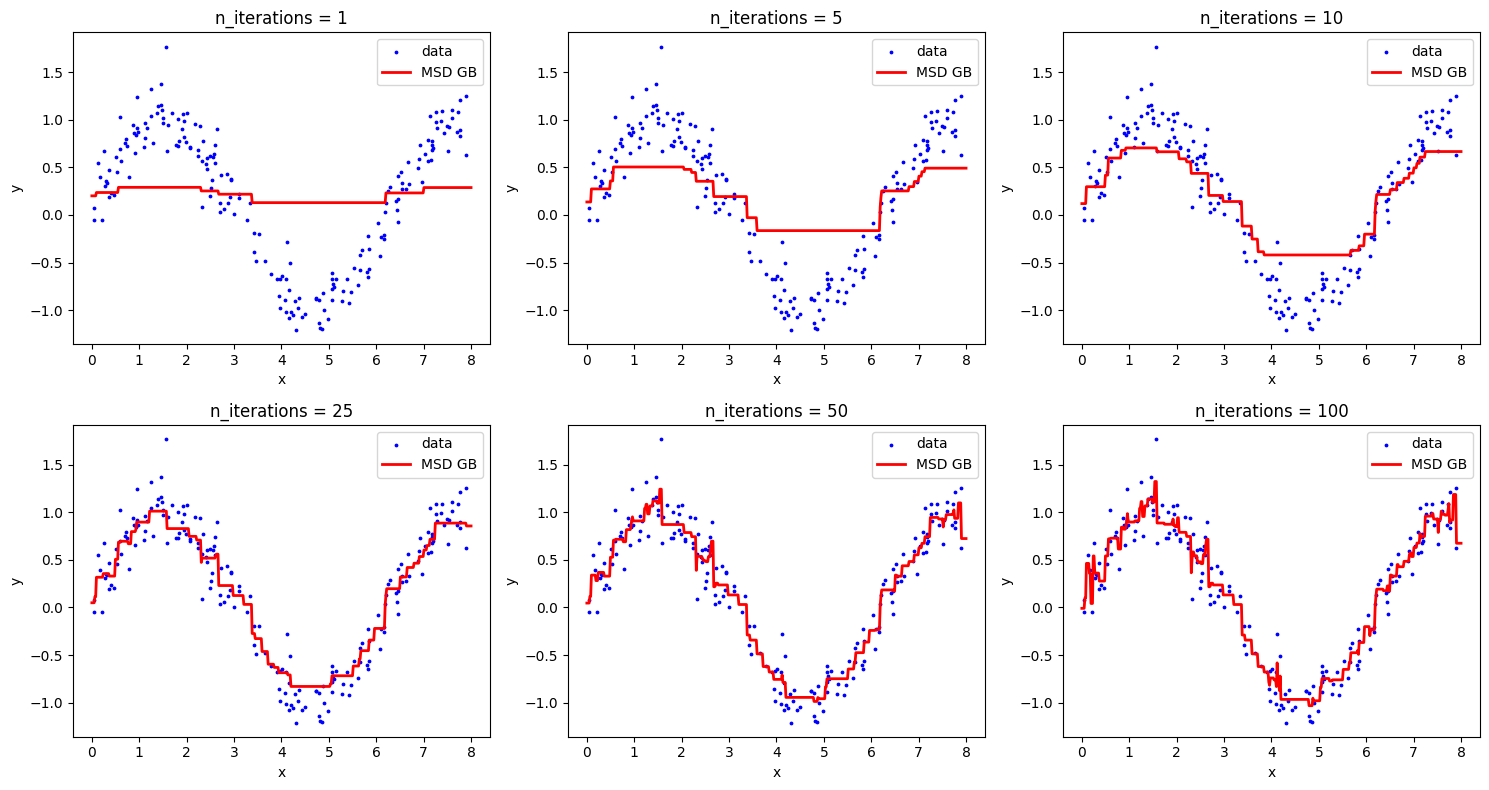

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, it in enumerate([1, 5, 10, 25, 50, 100]):
    model = MSDGradientBoostingRegressor(max_depth=3, n_iterations=it, learning_rate=0.1)
    model.fit(X, y)
    y_pred = model.predict(X_test)

    ax = axes[idx]
    ax.scatter(X, y, label="data", s=3, color="blue")
    ax.plot(X_test, y_pred, label="MSD GB", linewidth=2, color="red")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"n_iterations = {it}")
    ax.legend()

plt.tight_layout()
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    It is interesting to observe the convergence on the graphs, the model at 25 iterations is much more aligned with the sin function than at 10 iterations (where it is not complex enough to represent the dataset). I must point out that the models at higher iterations show some signs that it might be overfitted, with sudden peaks to represent specific points. Inplementing a validadion loss curve could help us to identify if that is truly the case.
  </p>
</div>

5. Compare your implementation with the one from the Scikit-learn library. With the same hyperparameter settings, you should obtain the exact same model (cf. Figure 2).

In [9]:
sk_model = GradientBoostingRegressor(
    loss="squared_error",
    learning_rate=0.1,
    n_estimators=100,
    max_depth=3,
    subsample=1.0,
    criterion="friedman_mse",
    random_state=42
)

sk_model.fit(X, y)

GradientBoostingRegressor(random_state=42)

In [10]:
y_pred_MSD = model.predict(X_test)
y_pred_sklearn = sk_model.predict(X_test)

max_diff = np.max(np.abs(y_pred_MSD - y_pred_sklearn))
print("Maximum absolute difference:", max_diff)

Maximum absolute difference: 2.220446049250313e-16


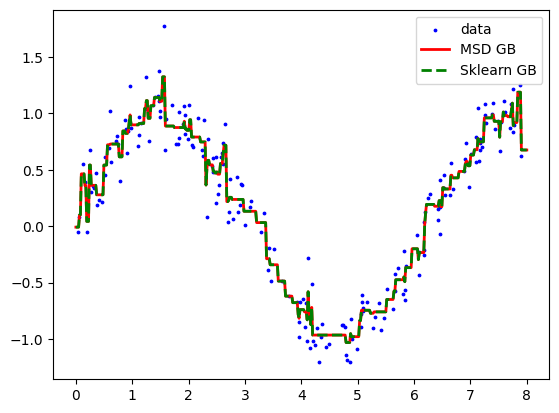

In [11]:
plt.figure()
plt.scatter(X, y, label="data", color="blue", s=3)
plt.plot(X_test, y_pred_MSD, label="MSD GB", linewidth=2, color="red")
plt.plot(X_test, y_pred_sklearn, '--', label="Sklearn GB", linewidth=2, color="green")
plt.legend()
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    As expected, the results obtained from the both models were pratically the same, with a minor difference in the scale of 10e-16, that proves that the implementation from scratch is alligned with what is done by the scikitlearn library
  </p>
</div>

=============================

# 2 Gradient Boosting for binary classification


1. Generate this synthetic dataset such that :
- each class contains 200 points
- µ1 = (−1, −1), µ2 = (1, 1), σ = 0.8

In [12]:
n_points = 200
mu1 = np.array([-1, -1])
mu2 = np.array([1, 1])
sigma = 0.8

X_neg = np.random.normal(loc=mu1, scale=sigma, size=(n_points, 2))
X_pos = np.random.normal(loc=mu2, scale=sigma, size=(n_points, 2))
y_neg = -np.ones(n_points)
y_pos =  np.ones(n_points)

X = np.vstack((X_neg, X_pos))
y = np.hstack((y_neg, y_pos))

print("X:", X.shape)
print("y", y.shape)

X: (400, 2)
y (400,)


2. Plot the scatter plot to obtain a result similar to that of Figure 3.


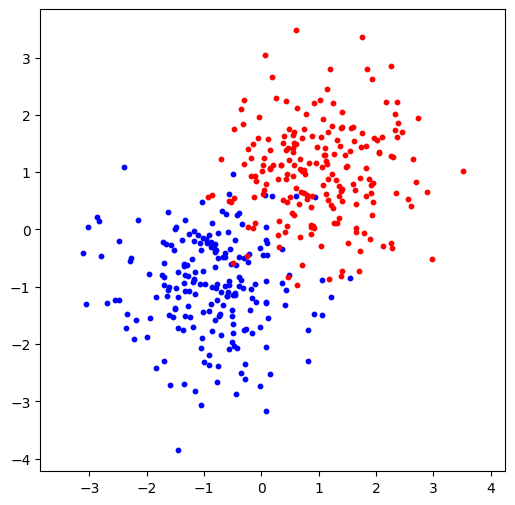

In [13]:
plt.figure(figsize=(6,6))

plt.scatter(X_neg[:, 0], X_neg[:, 1], color='blue', label='Class -1', s=10)
plt.scatter(X_pos[:, 0], X_pos[:, 1], color='red', label='Class +1', s=10)

plt.grid(False)
plt.axis('equal')
plt.show()

3. Start by testing the GradientBoostingClassifier from Scikit-learn on this dataset. Plot
the decision frontier as in Figure 4a. To do so :
- Generate a grid of 2D points
- Gather the predictions of the model for each of these points.
- Plot the decision boundaries
- Plot the scatter plot of the training dataset

In [14]:
# Train
gbc_sklearn = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gbc_sklearn.fit(X, y)

GradientBoostingClassifier(n_estimators=200, random_state=42)

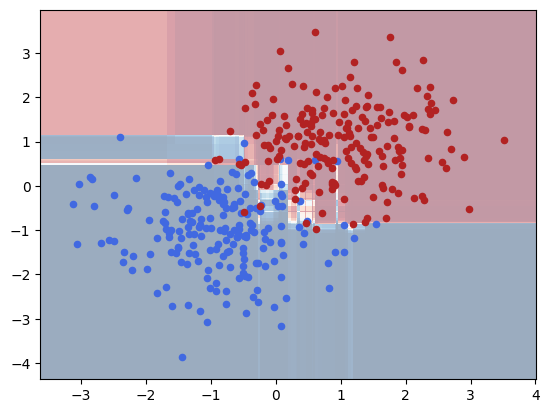

In [15]:
#plot
def mesh(X, h=0.02):
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )
    return np.c_[xx.ravel(), yy.ravel()], xx, yy

xtest_grid, xx, yy = mesh(X)

Z = gbc_sklearn.predict_proba(xtest_grid)[:, 0]
Z = Z.reshape(xx.shape)

plt.pcolormesh(xx, yy, Z, cmap=plt.cm.RdBu, alpha=.4)
plt.scatter(X[y == -1, 0], X[y == -1, 1], c='royalblue', s=20)
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='firebrick', s=20)
plt.show()


4. Using the same template as for regression, implement the MSDGradientBoostingClassifier class. For the first model, you can use the DummyClassifier(strategy="prior") model. The alphas can be set to 1 for all models.

In [18]:
class MSDGradientBoostingClassifier:
    def __init__(self, max_depth=3, n_iterations=100, learning_rate=0.1):
        self.max_depth = max_depth
        self.n_iterations = n_iterations
        self.learning_rate = learning_rate

    def _negative_gradient(self, y, y_pred_proba):
        return y - y_pred_proba

    def fit(self, X, y):
        # init. the first weak model using a dummy classifier
        self.init_ = DummyClassifier(strategy="prior")
        self.init_.fit(X, y)
        y_pred_proba = self.init_.predict_proba(X)[:, 1]

        self.estimators_ = []
        self.alphas_ = []

        # list to store loss at each iteration
        self.losses_ = []

        for _ in range(self.n_iterations):
            residuals = self._negative_gradient(y, y_pred_proba)

            tree = DecisionTreeRegressor(max_depth=self.max_depth)
            tree.fit(X, residuals)
            h = tree.predict(X)

            alpha = 1.0
            y_pred_proba += self.learning_rate * alpha * h

            self.estimators_.append(tree)
            self.alphas_.append(alpha)

            #  loss
            y_pred_sigmoid = 1 / (1 + np.exp(-y_pred_proba))
            loss = log_loss(y, y_pred_sigmoid)
            self.losses_.append(loss)

        self.sigmoid = lambda x: 1/(1+np.exp(-x))
        return self

    def predict_proba(self, X):
        y_pred = np.full(X.shape[0], self.init_.class_prior_[1])

        for alpha, tree in zip(self.alphas_, self.estimators_):
            h = tree.predict(X)
            y_pred += self.learning_rate * alpha * h

        y_pred_proba = self.sigmoid(y_pred)
        return np.vstack([1 - y_pred_proba, y_pred_proba]).T

    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return np.where(proba >= 0.5, 1, -1)

5. Plot the decision frontiers of both implementations as in Figure 4. Comment your results.


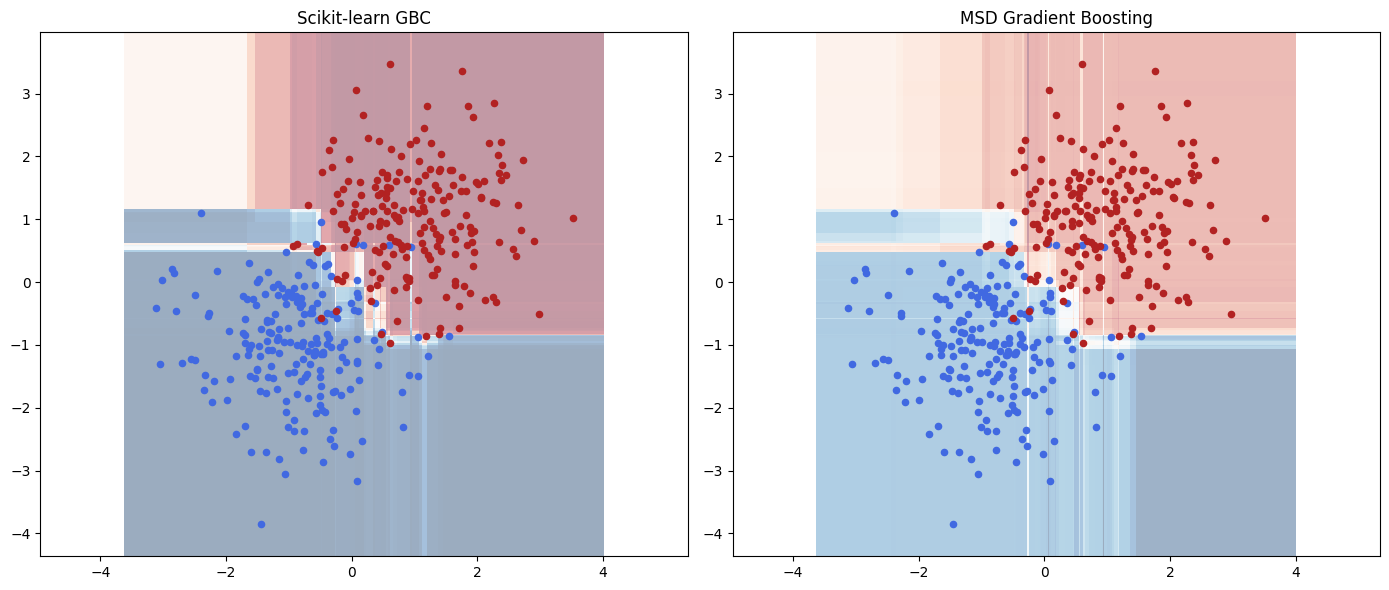

In [19]:
# Scikit-learn
gbc_sklearn = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
gbc_sklearn.fit(X, y)

# MSD
msd_gbc = MSDGradientBoostingClassifier(n_iterations=100, max_depth=3, learning_rate=0.1)
msd_gbc.fit(X, y)


xtest_grid, xx, yy = mesh(X)
Z_sklearn = -gbc_sklearn.predict_proba(xtest_grid)[:, 1].reshape(xx.shape)
Z_msd     = -msd_gbc.predict_proba(xtest_grid)[:, 1].reshape(xx.shape)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14,6))

for ax, Z, title in zip(axes, [Z_sklearn, Z_msd], ["Scikit-learn GBC", "MSD Gradient Boosting"]):
    ax.pcolormesh(xx, yy, Z, cmap=plt.cm.RdBu, alpha=0.4, shading='auto')
    ax.scatter(X[y == -1, 0], X[y == -1, 1], c='royalblue', s=20)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c='firebrick', s=20)
    ax.set_title(title)
    ax.axis('equal')

plt.tight_layout()
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    This time, we can see a much clearer different from my class' result and the one obtained from scikit learn. This is mainly due to unknown steps in the library implamentation, such as some sort of data preprocessing.
  </p>
</div>

In [26]:
# test dataset
n_test_points = 100
mu1 = np.array([-1, -1])
mu2 = np.array([1, 1])
sigma = 0.8

X_neg_test = np.random.normal(loc=mu1, scale=sigma, size=(n_test_points, 2))
X_pos_test = np.random.normal(loc=mu2, scale=sigma, size=(n_test_points, 2))
y_neg_test = -np.ones(n_test_points)
y_pos_test =  np.ones(n_test_points)

X_test = np.vstack((X_neg_test, X_pos_test))
y_test = np.hstack((y_neg_test, y_pos_test))

# Predict
y_pred_sklearn = gbc_sklearn.predict(X_test)
y_pred_msd = msd_gbc.predict(X_test)

# accuracy
acc_sklearn = accuracy_score(y_test, y_pred_sklearn)
acc_msd = accuracy_score(y_test, y_pred_msd)

print(f"Accuracy (scikit-learn): {acc_sklearn:.4f}")
print(f"Accuracy (MSD): {acc_msd:.4f}")

Accuracy (scikit-learn): 0.9700
Accuracy (MSD): 0.9700


<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    Even if the models are slightly different, they give very similar results, this might indicate that they are statistically equivalent to each other.
  </p>
</div>

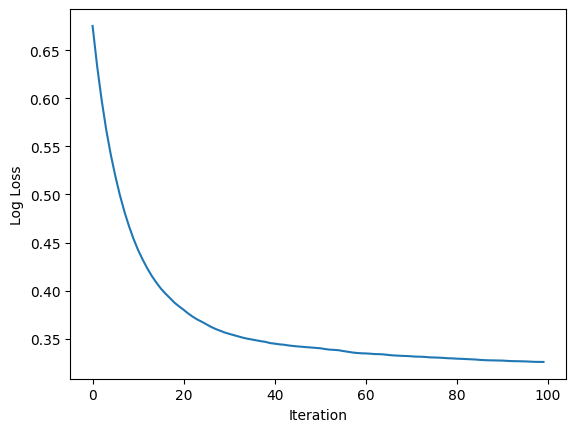

In [27]:
plt.plot(range(len(msd_gbc.losses_)), msd_gbc.losses_)
plt.xlabel("Iteration")
plt.ylabel("Log Loss")
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    We observe that the loss for this task decreases quickly and reaches convergence around 20 to 40 iterations. Before experimentation, I was expecting more iterations to be required, since the gradient boost requires a low learning rate, but that was not the case for this simple task.
  </p>
</div>